# Info

- Objetivo: Código utilizado para treinar e carregar modelos MGGP.

# Imports

In [1]:
import numpy as np 
import pandas as pd
from mggp import MGGP
from sklearn.preprocessing import StandardScaler
import numpy as np 
import os
import re 
from scipy import signal
import matplotlib.pyplot as plt
# from tensorflow.keras.models import load_model

# Execute

In [2]:
save_model = "mggp_models/dissertacao_best_model_FR1.pkl"
OUTPUT_FEATURES = 3

# Functions

In [3]:
def plot_top_correlations(results, u_train, y_train, top_n=10):
    """
    Plota as top N correlações mais fortes
    """
    # Encontrar as top N correlações por magnitude
    sorted_results = sorted(results.items(), 
                          key=lambda x: abs(x[1]['peak_value']), 
                          reverse=True)
    
    top_results = sorted_results[:top_n]
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Valores das correlações máximas
    names = [f"{key.split('_Input_')[1]}\n→{key.split('Output_')[1].split('_Input_')[0]}" 
             for key, _ in top_results]
    values = [result['peak_value'] for _, result in top_results]
    lags = [result['peak_lag'] for _, result in top_results]
    
    bars = axes[0].bar(range(len(names)), values, color='skyblue', alpha=0.7)
    axes[0].set_title(f'Top {top_n} Correlações Cruzadas (Máximos)')
    axes[0].set_ylabel('Correlação Normalizada')
    axes[0].set_xticks(range(len(names)))
    axes[0].set_xticklabels(names, rotation=45, ha='right')
    axes[0].grid(True, alpha=0.3)
    
    # Adicionar valores nas barras
    for i, (bar, lag) in enumerate(zip(bars, lags)):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}\n(lag:{lag})',
                    ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Heatmap de correlações
    correlation_matrix = np.zeros((len(y_train.columns), len(u_train.columns)))
    
    for output_idx, output_col in enumerate(y_train.columns):
        for input_idx, input_col in enumerate(u_train.columns):
            key = f"Output_{output_col}_Input_{input_col}"
            if key in results:
                correlation_matrix[output_idx, input_idx] = results[key]['peak_value']
    
    im = axes[1].imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', 
                       vmin=-1, vmax=1)
    axes[1].set_title('Mapa de Calor de Correlações Máximas')
    axes[1].set_xlabel('Entradas')
    axes[1].set_ylabel('Saídas')
    axes[1].set_xticks(range(len(u_train.columns)))
    axes[1].set_yticks(range(len(y_train.columns)))
    axes[1].set_xticklabels([f'In{i}' for i in range(len(u_train.columns))], fontsize=8, rotation=90)
    axes[1].set_yticklabels(y_train.columns)
    
    # Adicionar barra de cores
    plt.colorbar(im, ax=axes[1])
    
    plt.tight_layout()
    plt.show()

def analyze_cross_correlations(u_train, y_train, max_lag):
    """
    Analisa correlações cruzadas entre múltiplas entradas e saídas
    
    Parameters:
    u_train: DataFrame com 51 colunas de entradas
    y_train: DataFrame com 3 colunas de saídas  
    max_lag: número máximo de atrasos para calcular
    """
    
    # Garantir que são DataFrames
    u_df = pd.DataFrame(u_train)
    y_df = pd.DataFrame(y_train)
    
    print(f"Shape u_train: {u_df.shape}")
    print(f"Shape y_train: {y_df.shape}")
    print(f"Número de entradas: {u_df.shape[1]}")
    print(f"Número de saídas: {y_df.shape[1]}")
    
    results = {}
    
    # Para cada combinação entrada-saída
    for output_idx, output_col in enumerate(y_df.columns):
        print(f"\n--- Análise para Saída: {output_col} ---")
        
        output_signal = y_df[output_col].values
        
        for input_idx, input_col in enumerate(u_df.columns):
            input_signal = u_df[input_col].values
            
            # Calcular correlação cruzada normalizada
            correlation = signal.correlate(output_signal, input_signal, mode='full', method='auto')
            
            # Normalização para obter valores entre -1 e 1
            norm_factor = np.sqrt(np.sum(input_signal**2) * np.sum(output_signal**2))
            if norm_factor > 0:
                correlation_normalized = correlation / norm_factor
            else:
                correlation_normalized = correlation
            
            # Encontrar o atraso correspondente
            lags = signal.correlation_lags(len(output_signal), len(input_signal), mode='full')
            
            # Encontrar o pico de correlação
            peak_idx = np.argmax(np.abs(correlation_normalized))
            peak_lag = lags[peak_idx]
            peak_value = correlation_normalized[peak_idx]
            
            # Armazenar resultados
            key = f"Output_{output_col}_Input_{input_col}"
            results[key] = {
                'peak_lag': peak_lag,
                'peak_value': peak_value,
                'correlation': correlation_normalized,
                'lags': lags
            }
            
            # Mostrar apenas correlações fortes (ajuste o threshold conforme necessário)
            if abs(peak_value) > 0.4:  # Threshold para correlações significativas
                print(f"  Entrada {input_idx:2d} ({input_col}): "
                      f"Lag = {peak_lag:3d}, Correlação = {peak_value:6.3f}")
    
    return results

def media_movel_pandas(data, window_size=5, min_periods=1):

    if len(data.shape) == 1:
        series = pd.Series(data)
        return series.rolling(window=window_size, min_periods=min_periods).mean().values
    
    else:
        smoothed = np.zeros_like(data)
        for i in range(data.shape[1]):
            series = pd.Series(data[:, i])
            smoothed[:, i] = series.rolling(window=window_size, min_periods=min_periods).mean().values
        return smoothed


def remove_window_with_noise(df, folder):

    def indexes_to_remove(window_folder):
        arquivos = os.listdir(window_folder)

        index_to_remove = []

        for arquivo in arquivos:
            if arquivo.startswith("window_") and arquivo.endswith(".png"):
                match = re.search(r'window_(\d+)\.png', arquivo)
                if match:
                    numero = int(match.group(1))
                    index_to_remove.append(numero)

        return index_to_remove

    window_folder = rf"E:\projetos\mggp\images\tire windowed rotations\{folder}_front\window_with_noise"
    indexes_front = indexes_to_remove(window_folder)
    
    window_folder = rf"E:\projetos\mggp\images\tire windowed rotations\{folder}_rear\window_with_noise"
    indexes_rear = indexes_to_remove(window_folder)

    indexes = list(set(indexes_front + indexes_rear))
    
    df_filtered = df[~df.index.isin(indexes)]

    return df_filtered


def load_data(file_path, output_features, folder, filter=None, tire=None):  
    df = pd.read_csv(file_path)
    if 'Initial_Time' in df.columns and 'Final_Time' in df.columns:
        df.drop(columns=['Initial_Time', 'Final_Time'], inplace=True)
    # df = remove_window_with_noise(df, folder)
    
    if 'Ax' in df.columns:
        df.drop(columns=['Ax', 'Ay'], inplace=True)
    # df.drop(columns=["Fx_F", "Fx_R", "Fz_F", "Fz_R"], inplace=True)
    # df.drop(columns=["Fz_F", "Fz_R"], inplace=True)

    if tire is not None:
        df = df[df['Pneu'] == tire]        
        # df.drop(columns=['Pneu', 'Fx', 'Fz'], inplace=True)
        df.drop(columns=['Pneu'], inplace=True)
    
    if filter is not None:
        df = df.filter(regex=filter)

    X = df[[c for c in df.columns if c not in ['Fx', 'Fy', 'Fz']]].values
    y = df[['Fx', 'Fy', 'Fz']].values/1000 # Normalizado de N para kN
    
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

        
    return X, y, x_scaler, y_scaler

# Train

## Others

In [ ]:
# --------- TREINAMENTO PARA MODELO POR PNEU ----------------

for number in ['20_25']:
    
    os.makedirs(f'mggp_models_instant_nTerms_25/{number}', exist_ok=True)

    for tire_position in ["FR", "FL", "RR", "RL"]:
        for i in np.arange(1, 11):
            save_model = f"mggp_models_instant_nTerms_25/{number}/dissertacao_best_model_{tire_position}{i}.pkl"
            OUTPUT_FEATURES = 3

            u_data = []
            y_data = []

            folder = 'Job1_2023_07_29_12_15_29_Mix'
            path = f"iTire road test data/{folder}/Tire_Features_extraidas_{number}.csv"
            u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire_position)
            u_train, y_train = media_movel_pandas(u_train), media_movel_pandas(y_train)

            folder = 'Job1_2023_07_29_11_36_05_Mix'
            path = f"iTire road test data/{folder}/Tire_Features_extraidas_{number}.csv"
            u_train1, y_train1, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire_position)
            u_train1, y_train1 = u_train1[1250:2000, :], y_train1[1250:2000, :] # Slalom in 45kph, 2 times
            u_train1, y_train1 = media_movel_pandas(u_train1), media_movel_pandas(y_train1)

            u_train = np.concatenate([u_train, u_train1], axis=0)
            y_train = np.concatenate([y_train, y_train1], axis=0)

            u_data.append(u_train)
            y_data.append(y_train)

            u_combined = np.concatenate(u_data, axis=0)
            y_combined = np.concatenate(y_data, axis=0)

            mggp = MGGP(inputs=u_combined,
                        outputs=y_combined,
                        validation=(u_train, y_train),
                        nDelays=0,
                        generations=250,
                        populationSize=250,
                        evaluationMode="RMSE",
                        k=100,
                        evaluationType='INSTANT',
                        evaluationTypeTest="FreeRun",
                        # nTerms=10,
                        # maxHeight=2,
                        nTerms=25,
                        maxHeight=3,
                        mutationRate=0.2,
                        crossoverRate=0.9,
                        elitePercentage=10,
                        filename = save_model,
                        mode="FIR"
                        )

            mggp.run()

In [ ]:
# --------- TREINAMENTO PARA MODELO GENERALISTA ----------------

for number in ['20_25']:
    for nT in [25]:

        for mH in [ 3, 4, 6, 7, 8, 9]:
            folder_save = f'mggp_models_all_tires_nT{nT}_mH{mH}_narx'
            os.makedirs(f'{folder_save}/{number}', exist_ok=True)

            for i in np.arange(1, 11):
                save_model = f"{folder_save}/{number}/dissertacao_best_model_{i}.pkl"
                OUTPUT_FEATURES = 3

                u_data = []
                y_data = []

                for tire_position in ["FR", "FL", "RR", "RL"]:
                
                    folder = 'Job1_2023_07_29_12_15_29_Mix'
                    path = f"iTire road test data/{folder}/Tire_Features_extraidas_{number}.csv"
                    u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire_position)
                    u_train, y_train = media_movel_pandas(u_train), media_movel_pandas(y_train)

                    folder = 'Job1_2023_07_29_11_36_05_Mix'
                    path = f"iTire road test data/{folder}/Tire_Features_extraidas_{number}.csv"
                    u_train1, y_train1, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire_position)
                    u_train1, y_train1 = u_train1[1250:2000, :], y_train1[1250:2000, :] # Slalom in 45kph, 2 times
                    u_train1, y_train1 = media_movel_pandas(u_train1), media_movel_pandas(y_train1)
        
                    u_train = np.concatenate([u_train, u_train1], axis=0)
                    y_train = np.concatenate([y_train, y_train1], axis=0)
                    
                    if tire_position == "RR":
                        u_train -= 0.02

                    u_data.append(u_train)
                    y_data.append(y_train)

                u_combined = np.concatenate(u_data, axis=0)
                y_combined = np.concatenate(y_data, axis=0)
                
                # REMEMBER: Verify the set of subtration and sign functions in class Element (base.py)
                mggp = MGGP(inputs=u_combined,
                            outputs=y_combined,
                            validation=(u_combined, y_combined),
                            nDelays=1,
                            generations=250,
                            populationSize=250,
                            evaluationMode="RMSE",
                            k=100,
                            evaluationType='MShooting',
                            evaluationTypeTest="FreeRun",
                            nTerms=nT,
                            maxHeight=mH,
                            mutationRate=0.2,
                            crossoverRate=0.9,
                            elitePercentage=10,
                            filename = save_model,
                            mode="MIMO"
                            )

                mggp.run()

## Main Train

In [ ]:
u_data = []
y_data = []

# for tire_position in ["FR", "FL", "RR", "RL"]:
for tire_position in ["FR"]:
    number = '35_25'
    folder = 'Job1_2023_07_29_12_15_29_Mix'
    path = f"iTire road test data/{folder}/Tire_Features_extraidas_{number}.csv"
    
    u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire_position)
    u_train, y_train = media_movel_pandas(u_train), media_movel_pandas(y_train)

    folder = 'Job1_2023_07_29_11_36_05_Mix'
    path = f"iTire road test data/{folder}/Tire_Features_extraidas_{number}.csv"
    u_train1, y_train1, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire_position)
    u_train1, y_train1 = u_train1[1250:2000, :], y_train1[1250:2000, :] # Slalom in 45kph, 2 times
    u_train1, y_train1 = media_movel_pandas(u_train1), media_movel_pandas(y_train1)

    u_train = np.concatenate([u_train, u_train1], axis=0)
    y_train = np.concatenate([y_train, y_train1], axis=0)

    u_data.append(u_train)
    y_data.append(y_train)

u_combined = np.concatenate(u_data, axis=0)
y_combined = np.concatenate(y_data, axis=0)

# mggp = MGGP(
#             inputs=u_combined,
#             outputs=y_combined,
#             validation=(u_train, y_train),
#             nDelays=[1, 2, 3, 4, 5],
#             froe_mode=True,
#             generations=250,
#             populationSize=250,
#             evaluationMode="RMSE",
#             k=100,
#             evaluationType='MShooting',
#             evaluationTypeTest="FreeRun",
#             nTerms=20,
#             maxHeight=15,
#             mutationRate=0.2,
#             crossoverRate=0.9,
#             elitePercentage=10,
#             filename = "mggp_models/mggp_test.pkl",
#             mode="MIMO"
#             )

# REMEMBER: Verify the set of subtration and sign functions in class Element (base.py)
mggp = MGGP(inputs=u_combined,
            outputs=y_combined,
            validation=(u_combined, y_combined),
            nDelays=1,
            # froe_mode=True,
            generations=100,
            populationSize=250,
            evaluationMode="MSE",
            k=100,
            evaluationType='MShooting',
            evaluationTypeTest="FreeRun",
            nTerms=20,
            maxHeight=2,
            mutationRate=0.2,
            crossoverRate=0.9,
            elitePercentage=10,
            filename = "mggp_models/mggp_test.pkl",
            mode="MIMO"
            )

mggp.run()

# Load MGGP Model

In [5]:
folder = "Job1_2023_07_28_16_41_10_Mix"
# path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_medias_R_F_with_Fz_25.csv"
path = f"iTire road test data/{folder}/Tire_Features_extraidas_35_25.csv"
# u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, filter='_F$')
u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder)

# save_model = "mggp_models/mggp_test.pkl"
# save_model = "mggp_models_instant_nTerms_10_maxHeight_2/20_25/dissertacao_best_model_FR10.pkl"
save_model = "mggp_models_fir_instant/20_25/dissertacao_best_model_FR1.pkl"
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            filename=save_model)

loaded_model = mggp.load_model()

print(mggp.simplify_model(loaded_model))
# print(loaded_model)

Output 1:
2.98279e-01 * 
-4.86731e+00 * u13[i-1] +
3.52996e+01 * u24[i-1] +
-2.10803e+01 * u48[i-1] +
-1.33396e+02 * u19[i-1] +
-1.11255e+01 * u44[i-1] +
-2.77989e+01 * u5[i-1] +
-7.89946e+01 * u9[i-1] +
1.60644e+02 * u22[i-1] +
-1.36104e+02 * u32[i-1] +
-7.69834e+00 * u46[i-1] +
3.40628e+01 * u3[i-1] +
-1.75728e+01 * u39[i-1] +
8.78071e+01 * u28[i-1] +
6.13225e+01 * u20[i-1] +
-1.79014e+01 * u51[i-1] +
-1.95553e+01 * u37[i-1] +
6.62498e+01 * u2[i-1] +
-8.83876e+00 * u50[i-1] +
-7.09137e+01 * u17[i-1] +
4.98814e+01 * u7[i-1] +
Output 2:
-4.88643e-01 * 
-1.23001e+02 * u32[i-1] +
1.34979e+02 * u23[i-1] +
1.59644e+02 * u24[i-1] +
-1.11938e+02 * u33[i-1] +
-9.03413e+01 * u8[i-1] +
2.62375e+02 * u21[i-1] +
-5.27107e+01 * u14[i-1] +
-1.49138e+02 * u27[i-1] +
-1.25812e+02 * u10[i-1] +
-2.13184e+02 * u34[i-1] +
2.77236e+02 * u20[i-1] +
-7.24041e+01 * u9[i-1] +
2.28808e+02 * u26[i-1] +
-4.73010e+01 * u2[i-1] +
7.35495e+01 * u1[i-1] +
-1.84700e+02 * u30[i-1] +
-2.66543e+01 * u16[i-1] +
-5.96163e

In [14]:
files_ranges = {
    '35_25': {
        'x': [0, 28],
        'y': [29, 57],
        'z': [58, 86]
    },
    '20_25': {
        'x': [0, 16],
        'y': [17, 33],
        'z': [34, 50]
    },
    '10_25': {
        'x': [0, 8],
        'y': [9, 17],
        'z': [18, 26]
    }
}

def converter_identificadores(ids_u, ids_y, number, files_ranges):
    """
    Converte identificadores u e y para labels baseado nos ranges
    """
    if number not in files_ranges:
        raise ValueError(f"Number {number} não encontrado em files_ranges")
    
    ranges = files_ranges[number]
    number_range = int(number.split('_')[0])
    labels = np.arange(-number_range, number_range + 0.1, 2.5)
    
    u_convertidos = []
    y_convertidos = []
    
    # Converter identificadores u
    for id_u in ids_u:
        num_u = int(id_u[1:]) - 1  # Extrai o número após 'u'

        # Determinar a categoria (x, y, z) e a posição
        if ranges['x'][0] <= num_u <= ranges['x'][1]:
            categoria = 'X'
            posicao = num_u - ranges['x'][0]
        elif ranges['y'][0] <= num_u <= ranges['y'][1]:
            categoria = 'Y'
            posicao = num_u - ranges['y'][0] 
        elif ranges['z'][0] <= num_u <= ranges['z'][1]:
            categoria = 'Z'
            posicao = num_u - ranges['z'][0] 
        else:
            categoria = 'DESCONHECIDO'
            posicao = num_u
        
        if categoria != 'DESCONHECIDO' and posicao < len(labels):
            label = labels[posicao]
            u_convertidos.append(f"{categoria}({label}°)")
        else:
            u_convertidos.append(f"{id_u} ({categoria}[{posicao}])")
    
    # Converter identificadores y (assumindo mesma lógica que u)
    for id_y in ids_y:
        num_y = int(id_y[1:]) - 1  # Extrai o número após 'y'
        
        # Determinar a categoria (x, y, z) e a posição
        if ranges['x'][0] <= num_y <= ranges['x'][1]:
            categoria = 'X'
            posicao = num_y - ranges['x'][0]
        elif ranges['y'][0] <= num_y <= ranges['y'][1]:
            categoria = 'Y'
            posicao = num_y - ranges['y'][0]
        elif ranges['z'][0] <= num_y <= ranges['z'][1]:
            categoria = 'Z'
            posicao = num_y - ranges['z'][0]
        else:
            categoria = 'DESCONHECIDO'
            posicao = num_y
        
        if categoria != 'DESCONHECIDO' and posicao < len(labels):
            label = labels[posicao]
            y_convertidos.append(f"{categoria}({label}°)")
        else:
            y_convertidos.append(f"{id_y} ({categoria}[{posicao}])")
    
    return u_convertidos, y_convertidos

def extrair_e_converter_termos(texto, number, files_ranges):
    """
    Extrai termos e converte usando as labels
    """
    outputs = re.split(r'Output \d+:', texto)
    outputs = [output.strip() for output in outputs if output.strip()]
    
    resultados = {}
    
    for i, output in enumerate(outputs, 1):
        ids_u = sorted(set(re.findall(r'u\d+', output)), key=lambda x: int(x[1:]))
        ids_y = sorted(set(re.findall(r'y\d+', output)), key=lambda x: int(x[1:]))
        
        # Converter identificadores
        u_convertidos, y_convertidos = converter_identificadores(ids_u, ids_y, number, files_ranges)
        todas_features = list(set(u_convertidos + y_convertidos))
        resultados[f'Output {i}'] = {
            'ids_u_originais': ids_u,
            'ids_y_originais': ids_y,
            'ids_u_convertidos': u_convertidos,
            'ids_y_convertidos': y_convertidos,
            'todas_features': todas_features
        }
    
    return resultados
resultados = extrair_e_converter_termos(mggp.simplify_model(loaded_model), '20_25', files_ranges)
resultados

{'Output 1': {'ids_u_originais': ['u2',
   'u4',
   'u7',
   'u8',
   'u10',
   'u11',
   'u17',
   'u21',
   'u23',
   'u27',
   'u35',
   'u37',
   'u40',
   'u42',
   'u44',
   'u46',
   'u47',
   'u49',
   'u50',
   'u51'],
  'ids_y_originais': ['y1', 'y2'],
  'ids_u_convertidos': ['X(-17.5°)',
   'X(-12.5°)',
   'X(-5.0°)',
   'X(-2.5°)',
   'X(2.5°)',
   'X(5.0°)',
   'X(20.0°)',
   'Y(-12.5°)',
   'Y(-7.5°)',
   'Y(2.5°)',
   'Z(-20.0°)',
   'Z(-15.0°)',
   'Z(-7.5°)',
   'Z(-2.5°)',
   'Z(2.5°)',
   'Z(7.5°)',
   'Z(10.0°)',
   'Z(15.0°)',
   'Z(17.5°)',
   'Z(20.0°)'],
  'ids_y_convertidos': ['X(-20.0°)', 'X(-17.5°)'],
  'todas_features': ['X(-2.5°)',
   'X(2.5°)',
   'Y(-12.5°)',
   'X(-17.5°)',
   'Z(17.5°)',
   'Y(-7.5°)',
   'X(20.0°)',
   'Z(15.0°)',
   'Z(10.0°)',
   'X(-5.0°)',
   'X(5.0°)',
   'Z(-7.5°)',
   'Z(20.0°)',
   'Z(-15.0°)',
   'X(-12.5°)',
   'Z(-2.5°)',
   'Z(-20.0°)',
   'X(-20.0°)',
   'Z(7.5°)',
   'Y(2.5°)',
   'Z(2.5°)']},
 'Output 2': {'ids_u_origina

# Complexidade

In [10]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model, input_shape):
    """
    Calcula FLOPs de um modelo Keras.
    input_shape: tuple sem batch, ex: (timesteps, features)
    """
    # Cria função concreta
    @tf.function
    def model_fn(x):
        return model(x)

    concrete_fn = model_fn.get_concrete_function(
        tf.TensorSpec([1, *input_shape], model.inputs[0].dtype)
    )

    # Converte para grafo estático
    frozen_func = convert_variables_to_constants_v2(concrete_fn)
    graph_def = frozen_func.graph.as_graph_def()

    # Usa profiler
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops


In [26]:
TIRE_POSITION = "FL"
NUMBER = '20_25'
MODEL_DIR = f'ml_models/{NUMBER}/{TIRE_POSITION}/'
best_models = {
    'lstm': load_model(f'{MODEL_DIR}/lstm_1.keras'),
    'gru': load_model(f'{MODEL_DIR}/gru_1.keras'),
    'mlp': load_model(f'{MODEL_DIR}/mlp_1.keras')
}

for name, model in best_models.items():
    flops = get_flops(model, (70, 51))
    print(f"{name.upper()} FLOPs: {flops}")

LSTM FLOPs: 116753
GRU FLOPs: 179865
MLP FLOPs: 1230181


In [ ]:
import re

def count_flops(expr):
    terms = expr.replace('\n', ' ').split('+')
    mults = 0

    for term in terms:
        # conta quantos '*' existem no termo
        mults += term.count('*')

    sums = max(len(terms) - 1, 0)
    return mults + sums




FLOPs por amostra: 215


In [ ]:
import time
TIRES = ['FL', 'FR', 'RR', 'RL']
TIME_STEPS = 70

mggp_list = []
lstm_list = []
gru_list = []
mlp_list = []

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

for tire in TIRES:
    for i in range(10):

        folder = "Job1_2023_07_28_16_41_10_Mix"
        path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_extraidas_20_25.csv"
        u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire)
        u_train = u_train[:, :51].astype(float)

        X_val, y_val = media_movel_pandas(u_train), media_movel_pandas(y_train)
        X_val_seq, y_val_seq = create_sequences(X_val, y_val, TIME_STEPS)
        MODEL_DIR = f'ml_models/20_25/{tire}/'
        best_models = {
            'lstm': load_model(f'{MODEL_DIR}/lstm_{i+1}.keras'),
            'gru': load_model(f'{MODEL_DIR}/gru_{i+1}.keras'),
            'mlp': load_model(f'{MODEL_DIR}/mlp_{i+1}.keras')
        }

        init = time.time()
        lstm_pred = best_models['lstm'].predict(X_val_seq)
        end = time.time()
        lstm_list.append(end-init)
        
        
        init = time.time()
        gru_pred = best_models['gru'].predict(X_val_seq)
        end = time.time()
        gru_list.append(end-init)
        
        init = time.time()
        mlp_pred = best_models['mlp'].predict(X_val_seq)
        end = time.time()
        mlp_list.append(end-init)

        save_model = f"mggp_models/20_25/dissertacao_best_model_{tire}{i+1}.pkl"
        mggp = MGGP(inputs=u_train,
                            outputs=y_train,
                            filename=save_model)

        loaded_model = mggp.load_model()
        args = (y_val, X_val) 
        
        init = time.time()
        mggp_yp, mggp_yd = loaded_model.predict("FreeRun", *args)
        end = time.time()
        mggp_list.append(end-init)
        # print(mggp.simplify_model(loaded_model))

        expr = mggp.simplify_model(loaded_model)
        # print("FLOPs por amostra:", count_flops(expr))
        mggp_list.append(count_flops(expr))


print(f"LSTM Mean: {np.mean(lstm_list)} LSTM Std: {np.std(lstm_list)}")
print(f"GRU Mean: {np.mean(gru_list)} GRU Std: {np.std(gru_list)}")
print(f"MLP Mean: {np.mean(mlp_list)} MLP Std: {np.std(mlp_list)}")
print(f"MGGP Mean: {np.mean(mggp_list)} MGGP Std: {np.std(mggp_list)}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
147/156 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

KeyboardInterrupt: 

In [ ]:
TIRES = ['FL', 'FR', 'RR', 'RL']
mggp_list = []
NARX_list = []
FIR_list = []

import re

def classify_model(expr: str):
    """
    Retorna 'NARX' se houver termos auto-regressivos (y[i-d]),
    caso contrário retorna 'FIR'.
    """
    narx_pattern = r'y\d+\[i-\d+\]'
    
    if re.search(narx_pattern, expr):
        return 'NARX'
    else:
        return 'FIR'
    

def classify_by_output(expr: str):
    """
    Retorna um dicionário:
    {output_index: 'FIR' ou 'NARX'}
    """
    results = {}

    # Divide a expressão por outputs
    blocks = re.split(r'Output\s+\d+:', expr)

    # O primeiro split normalmente é vazio
    for i, block in enumerate(blocks[1:], start=1):
        if re.search(r'y\d+\[i-\d+\]', block):
            results[f'Output {i}'] = 'NARX'
        else:
            results[f'Output {i}'] = 'FIR'

    return results


for tire in TIRES:
# for tire in 'a':
    for i in range(10):

        folder = "Job1_2023_07_28_16_41_10_Mix"
        path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_extraidas_20_25.csv"
        u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire)
        u_train = u_train[:, :51].astype(float)        

        save_model = f"mggp_models_one_lag/20_25/dissertacao_best_model_{tire}{i+1}.pkl"
        # save_model = f"mggp_models_all_tires/20_25/dissertacao_best_model_{i+1}.pkl"
        mggp = MGGP(inputs=u_train,
                            outputs=y_train,
                            filename=save_model)

        loaded_model = mggp.load_model()
        # print(mggp.simplify_model(loaded_model))

        expr = mggp.simplify_model(loaded_model)
        output_types = classify_by_output(expr)
        
        # if model_type == "FIR":
        #     FIR_list.append(model_type)
        # elif model_type == "NARX":
        #     NARX_list.append(model_type)

        for out, model_type in output_types.items():
            mggp_list.append({
                "tire": tire,
                "model_id": i + 1,
                "output": out,
                "type": model_type
            })

# print(f"FIR: {len(FIR_list)}, NARX: {len(NARX_list)}")

In [16]:
df = pd.DataFrame(mggp_list)
len(df[(df['output']=='Output 2') & (df['type']=='FIR')]), len(df[(df['output']=='Output 2') & (df['type']=='NARX')]), 

(2, 38)

In [38]:
lstm_flops = [168137, 207513, 187313, 116753]
gru_flops = [118521, 92457, 147657, 179865]
mlp_flops = [1105797, 1355589, 860101, 1230181]
mggp_flops_mean, mggp_flops_std = (206.5, 7.7)

In [42]:
# np.mean(lstm_flops), np.std(lstm_flops),
# np.mean(gru_flops), np.std(gru_flops),
np.mean(mlp_flops), np.std(mlp_flops),

(1137917.0, 183103.22876454145)

In [ ]:
# TEMPOS DE TREINAMENTO
gru_time, gru_std = (3.9, 0.3)
lstm_time, lstm_std = (3.7, 0.5)
mlp_time, mlp_std = (3.8, 0.6)
mggp_time, mggp_std = (32.6, 3.5)

# TOTAL DE PARÂMETROS
mggp_params_mean = 49.75
mggp_params_std = 5.76

lstm_params_mean = 291341
lstm_params_std = 90688

gru_params_mean = 263045
gru_params_std = 93915

mlp_params_mean = 1656785
mlp_params_std = 274371

(3.9, 0.3)

In [51]:

mggp_list = [31, 32, 31, 31, 31, 43, 32, 33, 31, 31]
mggp_time, mggp_std = np.mean(mggp_list), np.std(mggp_list)
mggp_time, mggp_std

(32.6, 3.5270384177096794)

In [43]:

files_ranges = {
    '35_25': {
        'x': [0, 28],
        'y': [29, 57],
        'z': [58, 86]
    },
    '20_25': {
        'x': [0, 16],
        'y': [17, 33],
        'z': [34, 50]
    },
    '10_25': {
        'x': [0, 8],
        'y': [9, 17],
        'z': [18, 26]
    }
}

def converter_identificadores(ids_u, ids_y, number, files_ranges):
    """
    Converte identificadores u e y para labels baseado nos ranges
    """
    if number not in files_ranges:
        raise ValueError(f"Number {number} não encontrado em files_ranges")
    
    ranges = files_ranges[number]
    number_range = int(number.split('_')[0])
    labels = np.arange(-number_range, number_range + 0.1, 2.5)
    
    u_convertidos = []
    y_convertidos = []
    
    # Converter identificadores u
    for id_u in ids_u:
        num_u = int(id_u[1:]) - 1  # Extrai o número após 'u'

        # Determinar a categoria (x, y, z) e a posição
        if ranges['x'][0] <= num_u <= ranges['x'][1]:
            categoria = 'X'
            posicao = num_u - ranges['x'][0]
        elif ranges['y'][0] <= num_u <= ranges['y'][1]:
            categoria = 'Y'
            posicao = num_u - ranges['y'][0] 
        elif ranges['z'][0] <= num_u <= ranges['z'][1]:
            categoria = 'Z'
            posicao = num_u - ranges['z'][0] 
        else:
            categoria = 'DESCONHECIDO'
            posicao = num_u
        
        if categoria != 'DESCONHECIDO' and posicao < len(labels):
            label = labels[posicao]
            u_convertidos.append(f"{categoria}({label}°)")
        else:
            u_convertidos.append(f"{id_u} ({categoria}[{posicao}])")
    
    # Converter identificadores y (assumindo mesma lógica que u)
    for id_y in ids_y:
        num_y = int(id_y[1:]) - 1  # Extrai o número após 'y'
        
        # Determinar a categoria (x, y, z) e a posição
        if ranges['x'][0] <= num_y <= ranges['x'][1]:
            categoria = 'X'
            posicao = num_y - ranges['x'][0]
        elif ranges['y'][0] <= num_y <= ranges['y'][1]:
            categoria = 'Y'
            posicao = num_y - ranges['y'][0]
        elif ranges['z'][0] <= num_y <= ranges['z'][1]:
            categoria = 'Z'
            posicao = num_y - ranges['z'][0]
        else:
            categoria = 'DESCONHECIDO'
            posicao = num_y
        
        if categoria != 'DESCONHECIDO' and posicao < len(labels):
            label = labels[posicao]
            y_convertidos.append(f"{categoria}({label}°)")
        else:
            y_convertidos.append(f"{id_y} ({categoria}[{posicao}])")
    
    return u_convertidos, y_convertidos

def extrair_e_converter_termos(texto, number, files_ranges):
    """
    Extrai termos e converte usando as labels
    """
    outputs = re.split(r'Output \d+:', texto)
    outputs = [output.strip() for output in outputs if output.strip()]
    
    resultados = {}
    
    for i, output in enumerate(outputs, 1):
        ids_u = sorted(re.findall(r'u\d+', output), key=lambda x: int(x[1:]))
        ids_y = sorted(re.findall(r'y\d+', output), key=lambda x: int(x[1:]))
        
        # Converter identificadores
        u_convertidos, y_convertidos = converter_identificadores(ids_u, ids_y, number, files_ranges)
        todas_features = list(set(u_convertidos + y_convertidos))
        resultados[f'Output {i}'] = {
            'ids_u_originais': ids_u,
            'ids_y_originais': ids_y,
            'ids_u_convertidos': u_convertidos,
            'ids_y_convertidos': y_convertidos,
            'todas_features': todas_features
        }
    
    return resultados

TIRES = ['FL', 'FR', 'RR', 'RL']
mggp_list = []
for tire in TIRES:
    for i in range(10):

        folder = "Job1_2023_07_28_16_41_10_Mix"
        path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_extraidas_35_25.csv"
        u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder)

        save_model = f"mggp_models/20_25/dissertacao_best_model_{tire}{i+1}.pkl"
        mggp = MGGP(inputs=u_train,
                            outputs=y_train,
                            filename=save_model)

        loaded_model = mggp.load_model()

        resultados = extrair_e_converter_termos(mggp.simplify_model(loaded_model), '20_25', files_ranges)
        # resultados['Output 1']['ids_u_originais']

        params = 21 + len(resultados['Output 1']['ids_u_originais']) + len(resultados['Output 1']['ids_y_originais'])
        mggp_list.append(params)

In [44]:
np.mean(mggp_list), np.std(mggp_list)

(49.75, 5.7608593109014565)

## Calculando o número de termos autorregresivos por modelo

In [21]:
import pandas as pd
import re

def check_y_terms_by_output(expr: str):
    """
    Retorna um dicionário indicando se cada termo y foi utilizado em cada output.
    {output_index: {'y1': bool, 'y2': bool, 'y3': bool}}
    """
    results = {}
    
    # Divide a expressão por outputs
    blocks = re.split(r'Output\s+\d+:', expr)
    
    # O primeiro split normalmente é vazio
    for i, block in enumerate(blocks[1:], start=1):
        output_key = f'Output {i}'
        results[output_key] = {
            'y1': bool(re.search(r'\by1\b', block)),
            'y2': bool(re.search(r'\by2\b', block)),
            'y3': bool(re.search(r'\by3\b', block))
        }
    
    return results

# Lista para armazenar os resultados
y_usage_list = []

# Seu loop principal
for tire in TIRES:
    for i in range(10):
        folder = "Job1_2023_07_28_16_41_10_Mix"
        path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_extraidas_20_25.csv"
        u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire=tire)
        u_train = u_train[:, :51].astype(float)        

        save_model = f"mggp_models_one_lag/20_25/dissertacao_best_model_{tire}{i+1}.pkl"
        mggp = MGGP(inputs=u_train,
                    outputs=y_train,
                    filename=save_model)

        loaded_model = mggp.load_model()
        expr = mggp.simplify_model(loaded_model)
        
        # Verifica quais termos y foram utilizados em cada output
        y_usage = check_y_terms_by_output(expr)
        
        # Adiciona ao dataframe
        for output_name, usage in y_usage.items():
            y_usage_list.append({
                "tire": tire,
                "model_id": i + 1,
                "output": output_name,
                "y1_used": 1 if usage['y1'] else 0,
                "y2_used": 1 if usage['y2'] else 0,
                "y3_used": 1 if usage['y3'] else 0
            })

# Cria o dataframe final
df_usage = pd.DataFrame(y_usage_list)

# Agrega as contagens por output (somando os usos únicos por modelo)
df_final = df_usage.groupby('output').agg({
    'y1_used': 'sum',
    'y2_used': 'sum',
    'y3_used': 'sum'
}).reset_index()

# Renomeia as colunas para ficar mais claro
df_final.columns = ['Output', 'y1_count', 'y2_count', 'y3_count']

print("Tabela final - Contagem de uso único por modelo:")
print(df_final)
print(f"\nNúmero total de modelos analisados: {len(df_usage['model_id'].unique())}")
print(f"Número de pneus analisados: {len(df_usage['tire'].unique())}")



Tabela final - Contagem de uso único por modelo:
     Output  y1_count  y2_count  y3_count
0  Output 1         4        13         9
1  Output 2         9        20        26
2  Output 3         5        29        17

Número total de modelos analisados: 10
Número de pneus analisados: 4


# Train MGGP Classifier

In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
OUTPUT_FEATURES = 3

df = pd.read_csv('smart tire/Global_data_PVDF.csv')
df = df.dropna(axis=1)
columns_with_infinity = df.columns[df.isin([np.inf, -np.inf]).any()]
df = df.drop(columns=columns_with_infinity)

X = df.iloc[:, :-1]  
y = df.iloc[:, -1]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if len(y_train.values.shape):
    y_train = to_categorical(y_train, num_classes=max(y_train.values)+1)

if len(y_test.values.shape):
    y_test = to_categorical(y_test, num_classes=max(y_test.values)+1)
    
# for i in range(10):
mggp = MGGP(
            inputs=X_train.values,
            outputs=y_train,
            validation=(X_test.values, y_test),
            problem_type='classification',
            nDelays=1,
            classification_metric='accuracy',
            generations=250,
            populationSize=100,
            evaluationMode="RMSE",
            evaluationType='INSTANT',
            evaluationTypeTest='INSTANT',
            nTerms=20,
            maxHeight=2,
            mutationRate=0.2,
            crossoverRate=0.9,
            # pruning_probability=0.5,
            # pruning_tolerance= 1e5, 
            # filename = f"mggp_models_classification/mggp_classifier{i}.pkl",
            filename = f"mggp_models_classification/test.pkl",
            mode="FIR"
            )

mggp.run()

2026-04-08 10:24:20.328447: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 10:24:20.329656: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 10:24:20.349306: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 10:24:20.349328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 10:24:20.349811: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

System Mode: FIR. N° Inputs: 16. N° Outputs: 8
Input Samples: 3197. Output Samples: 3197



Evaluating Initial Population: 100%|██████████| 100/100 [00:06<00:00, 16.27it/s]


   	     	                fitness                 
   	     	----------------------------------------
gen	evals	min     	avg     	max     
1  	100  	0.225594	0.269515	0.373592


Evaluating Population:  57%|█████▋    | 50/87 [00:03<00:02, 15.96it/s]


KeyboardInterrupt: 

In [19]:
from sklearn.metrics import accuracy_score
mggp_accuracies = []
for i in range(10):
    folder = "Job1_2023_07_28_16_41_10_Mix"
    path = f"iTire road test data/{folder}/Tire_Features_extraidas_35_25.csv"
    u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder)

    save_model =  f"mggp_models_classification/mggp_classifier{i}.pkl"
    mggp = MGGP(inputs=u_train,
                outputs=y_train,
                mode="FIR",
                filename=save_model)
    
    df = pd.read_csv('smart tire/Global_data_PVDF.csv')
    df = df.dropna(axis=1)
    columns_with_infinity = df.columns[df.isin([np.inf, -np.inf]).any()]
    df = df.drop(columns=columns_with_infinity)

    X = df.iloc[:, :-1]  
    y = df.iloc[:, -1]  

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if len(y_train.values.shape):
        y_train = to_categorical(y_train, num_classes=max(y_train.values)+1)

    if len(y_test.values.shape):
        y_test = to_categorical(y_test, num_classes=max(y_test.values)+1)
    
    args = (y_test, X_test.values) 
    loaded_model = mggp.load_model()
    loaded_model._logistic_model = True
    y_pred, y_true = loaded_model.predict_classes('INSTANT', *args)
    
    mggp_accuracies.append(accuracy_score(y_true, y_pred))

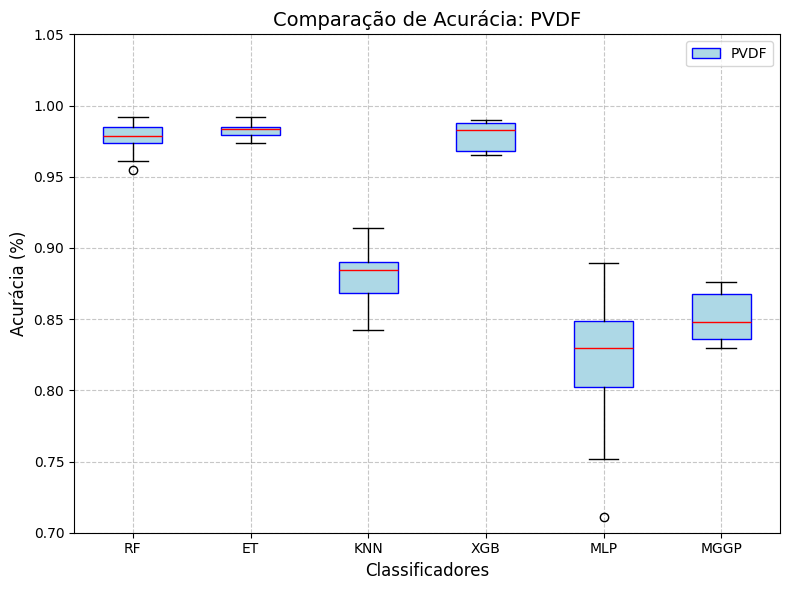

In [ ]:
all_scores_pvdf = {
    'RF': [0.95491803, 0.97336066, 0.97540984, 0.96106557, 0.98565574, 0.98360656, 0.99180328, 0.9795082, 0.97745902, 0.98770492],
    'ET': [0.98360656, 0.97745902, 0.97336066, 0.97336066, 0.98770492, 0.98565574, 0.98360656, 0.98360656, 0.98360656, 0.99180328],
    'KNN': [0.86065574, 0.8647541, 0.84221311, 0.87909836, 0.88729508, 0.90983607, 0.88114754, 0.88729508, 0.89139344, 0.91393443],
    'XGB': [0.96516393, 0.97131148, 0.96721311, 0.96516393, 0.98770492, 0.9795082, 0.9897541, 0.98770492, 0.98565574, 0.9897541],
    'MLP': [0.81147541, 0.83401639, 0.79918033, 0.85245902, 0.82581967, 0.85655738, 0.75204918, 0.83811475, 0.71106557, 0.88934426],
    'MGGP': mggp_accuracies
}

labels = ['RF', 'ET', 'KNN', 'XGB', 'MLP', 'MGGP']
pvdf_scores = [all_scores_pvdf['RF'], 
               all_scores_pvdf['ET'], 
               all_scores_pvdf['KNN'], 
               all_scores_pvdf['XGB'], 
               all_scores_pvdf['MLP'],
               all_scores_pvdf['MGGP'],
               ]

plt.figure(figsize=(8, 6))

# positions_accx = np.arange(len(labels)) * 2 - 0.3  # Posições deslocadas para a esquerda
# box1 = plt.boxplot(accx_scores, positions=positions_accx, widths=0.5, patch_artist=True,
#                    boxprops=dict(facecolor='lightblue', color='blue'),
#                    medianprops=dict(color='red'))

positions_pvdf = np.arange(len(labels))   # Posições deslocadas para a direita
box2 = plt.boxplot(pvdf_scores, positions=positions_pvdf, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red'))

plt.title('Comparação de Acurácia: PVDF', fontsize=14)
plt.xlabel('Classificadores', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
# plt.legend([box1["boxes"][0], box2["boxes"][0]], ['AccX', 'PVDF'], loc='upper right')
plt.legend([box2["boxes"][0]], ['PVDF'], loc='upper right')
# Ajustar limites do eixo Y para melhor visualização
plt.ylim(0.7, 1.05)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('Boxplot_Comparison_PVDF.png', bbox_inches='tight', dpi=300)
plt.show()

## Load Classifier

In [43]:
folder = "Job1_2023_07_28_16_41_10_Mix"
# path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_medias_R_F_with_Fz_25.csv"
path = f"iTire road test data/{folder}/Tire_Features_extraidas_35_25.csv"
# u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, filter='_F$')
u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder)

save_model = "mggp_models_classification/mggp_classifier4.pkl"
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            filename=save_model)

loaded_model = mggp.load_model()

print(mggp.simplify_model(loaded_model))
# print(loaded_model)

Output 1:
3.80132e-01 * 
1.17873e-01 * u12[i-1] +
5.79008e-01 * u5[i-1] * u7[i-1] +
1.70210e+00 * u3[i-1] +
-9.80848e-02 * u8[i-1] +
-1.96379e-02 * u1[i-1] * u15[i-1] +
-6.22994e+00 * u14[i-1] * u9[i-1] +
-3.77954e-01 * u3[i-1] * u13[i-1] * u3[i-1] * u9[i-1] +
-1.47960e-01 * u13[i-1] +
-2.25446e-03 * u10[i-1] * u10[i-1] +
-2.39738e-01 * u11[i-1] * u5[i-1] +
-3.20716e-01 * u9[i-1] +
3.36282e-01 * u6[i-1] * u14[i-1] * u7[i-1] * u8[i-1] +
8.84707e-04 * u10[i-1] * u10[i-1] * u16[i-1] +
-6.58955e-02 * u7[i-1] +
-1.37601e-05 * u12[i-1] * u12[i-1] * u10[i-1] +
5.75543e-04 * u6[i-1] * u6[i-1] +
5.89589e-02 * u11[i-1] +
Output 2:
1.16008e+00 * 
2.57569e-01 * u12[i-1] +
2.16789e-01 * u12[i-1] * u4[i-1] * u4[i-1] * u4[i-1] +
-9.30237e-02 * u10[i-1] +
-3.93976e-02 * u1[i-1] * u1[i-1] +
7.09207e-01 * u4[i-1] * u4[i-1] +
5.35112e+00 * u10[i-1] * u14[i-1] +
-4.75763e-01 * u13[i-1] +
6.38153e-02 * u10[i-1] * u13[i-1] +
-2.82268e-01 * u9[i-1] +
-4.73976e+00 * u7[i-1] * u2[i-1] * u3[i-1] * u10[i-1] +
-8

# Análise de Correlação Cruzada

In [11]:
folder = 'Job1_2023_07_29_12_15_29_Mix'
path = f"E:/matlab files/iTire road test data/{folder}/Tire_Features_extraidas_20_25.csv"

# Carregar dados (adaptar conforme sua função load_data)
u_train, y_train, _, _ = load_data(path, OUTPUT_FEATURES, folder, tire='RL')
# u_train, y_train = media_movel_pandas(u_train), media_movel_pandas(y_train)

# Analisar correlações
print("=== ANÁLISE DE CORRELAÇÕES CRUZADAS ===")
results = analyze_cross_correlations(u_train, y_train, max_lag=20)

=== ANÁLISE DE CORRELAÇÕES CRUZADAS ===
Shape u_train: (1568, 51)
Shape y_train: (1568, 3)
Número de entradas: 51
Número de saídas: 3

--- Análise para Saída: 0 ---
  Entrada  0 (0): Lag =  -4, Correlação = -0.503
  Entrada  2 (2): Lag = -176, Correlação =  0.425
  Entrada  3 (3): Lag = -112, Correlação =  0.529
  Entrada  4 (4): Lag = -22, Correlação =  0.591
  Entrada  5 (5): Lag = -31, Correlação =  0.598
  Entrada  6 (6): Lag = -34, Correlação =  0.567
  Entrada  7 (7): Lag = -170, Correlação =  0.535
  Entrada  8 (8): Lag = -26, Correlação =  0.536
  Entrada  9 (9): Lag = -113, Correlação =  0.523
  Entrada 11 (11): Lag = -34, Correlação = -0.568
  Entrada 12 (12): Lag = -17, Correlação = -0.628
  Entrada 13 (13): Lag =  -5, Correlação = -0.539
  Entrada 14 (14): Lag = 271, Correlação = -0.508
  Entrada 15 (15): Lag = 271, Correlação = -0.452
  Entrada 16 (16): Lag =  -5, Correlação = -0.458
  Entrada 20 (20): Lag = 164, Correlação = -0.416
  Entrada 21 (21): Lag = 407, Correlação

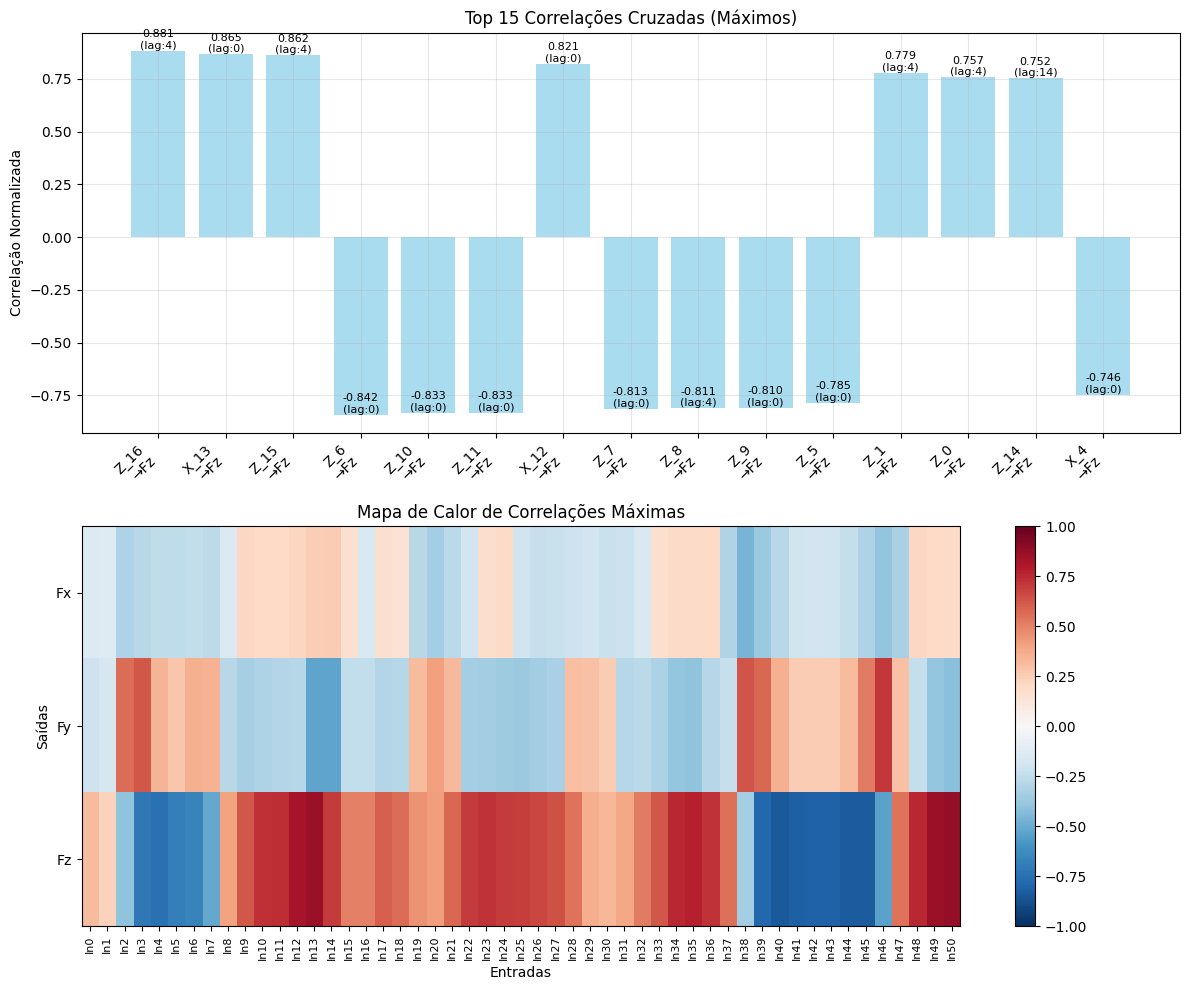

In [17]:
# Plotar resultados
plot_top_correlations(results, u_train, y_train, top_n=15)